In [48]:
import keras
from keras.layers import InputLayer, Conv2D, MaxPooling2D
from keras.layers import Flatten, Dense
from keras.models import Sequential
from keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

In [49]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [50]:
x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [51]:
model = Sequential([
    InputLayer(shape=(28, 28, 1)),

    Conv2D(filters=6, kernel_size=(5, 5), activation='tanh'),

    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=16, kernel_size=(5, 5), activation='tanh'),

    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),

    Dense(units=256, activation='tanh'),
    Dense(units=120, activation='tanh'),
    Dense(units=84, activation='tanh'),

    Dense(units=10, activation='softmax')
])


In [52]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [53]:
h = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.7642 - loss: 0.8293 - val_accuracy: 0.8910 - val_loss: 0.3857
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9283 - loss: 0.2572 - val_accuracy: 0.9270 - val_loss: 0.2592
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9575 - loss: 0.1608 - val_accuracy: 0.9350 - val_loss: 0.2187
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9647 - loss: 0.1196 - val_accuracy: 0.9400 - val_loss: 0.2090
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9732 - loss: 0.0903 - val_accuracy: 0.9470 - val_loss: 0.1901
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9790 - loss: 0.0716 - val_accuracy: 0.9440 - val_loss: 0.1713
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9845 - loss: 0.0585 - val_accuracy: 0.9520 - val_loss: 0.1711
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9843 - loss: 0.0534 - val_accuracy: 0.9570 - v

In [54]:
loss, accuracy = model.evaluate(x_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9410 - loss: 0.1572


In [55]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

correct = np.sum(predicted_labels == y_test)

incorrect = np.sum(predicted_labels != y_test)

print("\n----- PREDICTION RESULTS -----")
print("Total Test Images:", len(y_test))
print("Correct Predictions:", correct)
print("Incorrect Predictions:", incorrect)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

----- PREDICTION RESULTS -----
Total Test Images: 1000
Correct Predictions: 941
Incorrect Predictions: 59


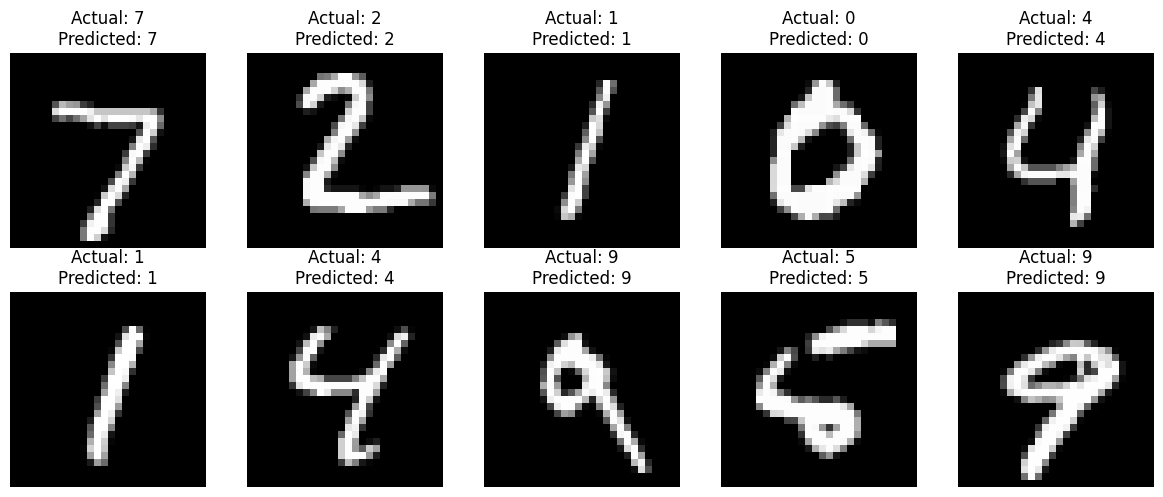

In [56]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[i].squeeze(),
        cmap='gray'
    )

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Predicted: {predicted_labels[i]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

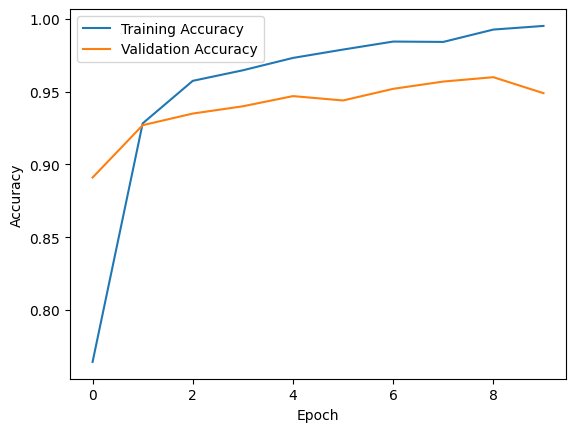

In [57]:
plt.plot(h.history['accuracy'], label='Training Accuracy')
plt.plot(h.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

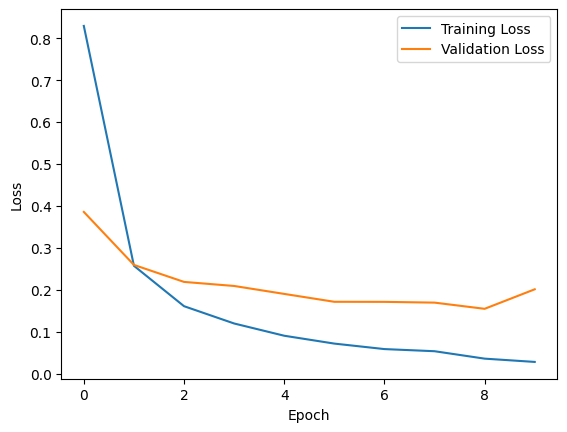

In [58]:
plt.plot(h.history['loss'], label='Training Loss')
plt.plot(h.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()